# Retail Transaction Analysis using Python

## Problem Statement
This project analyses retail transaction data to understand product category performance, customer spending behaviour, and sales trends over time.

## Intended User
The intended user is a retail manager or business analyst who wants to use transaction data to support business decisions.

## Dataset
The dataset contains retail transaction records downloaded from Kaggle, including information such as transaction date, customer demographics, product category, quantity, price per unit, and total amount.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Initial Data Inspection

In [11]:
df = pd.read_csv("retail_sales_dataset.csv", encoding="latin1", sep=",")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023/11/24,CUST001,Male,34,Beauty,3,50,150
1,2,2023/2/27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023/1/13,CUST003,Male,50,Electronics,1,30,30
3,4,2023/5/21,CUST004,Male,37,Clothing,1,500,500
4,5,2023/5/6,CUST005,Male,30,Beauty,2,50,100


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


## Data Preprocessing

The **Date** column is converted into datetime format so that time-based analysis can be performed later.

In [31]:
df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Month             1000 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(5), object(3)
memory usage: 74.3+ KB


In [14]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


The dataset contains 1,000 records and no missing values.  
After preprocessing, the **Date** column is stored in datetime format successfully.  
The descriptive statistics show that the average customer age is around 41 years old, and the average transaction value is 456.

## Basic Descriptive Analysis

In [15]:
df["Product Category"].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [16]:
df["Gender"].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

In [17]:
df["Total Amount"].sum()

np.int64(456000)

The results show that Clothing has the highest number of transactions, followed by Electronics and Beauty.  
The gender distribution is relatively balanced, and the total sales amount in the dataset is 456,000.

In [18]:
df["Month"] = df["Date"].dt.month
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5


## Monthly Sales Analysis

In [19]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()
monthly_sales


Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

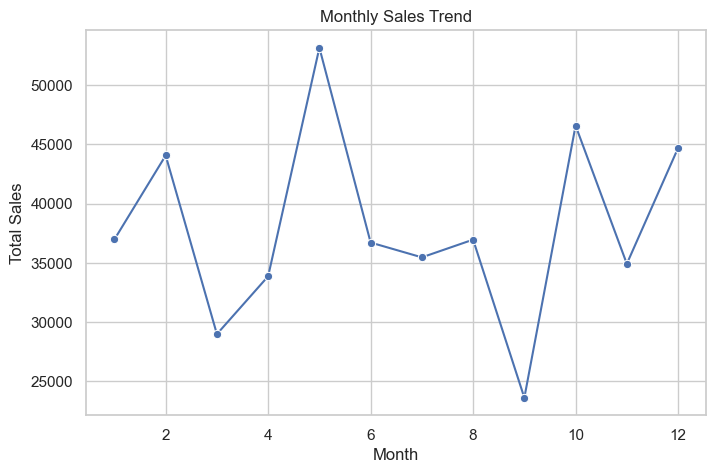

In [20]:
plt.figure(figsize=(8,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

The monthly sales trend shows noticeable fluctuations across the year.  
This suggests that customer demand changes over time, with some months generating higher revenue than others.

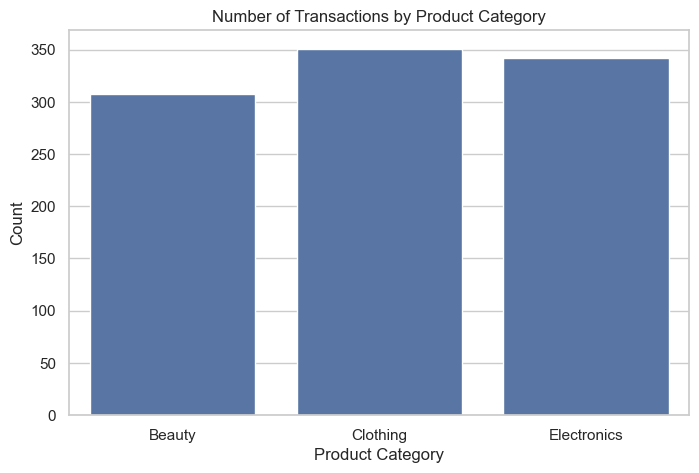

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Product Category")
plt.title("Number of Transactions by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.show()

Clothing has the highest number of transactions, followed by Electronics and Beauty.  
This indicates that Clothing is the most frequently purchased product category in the dataset.

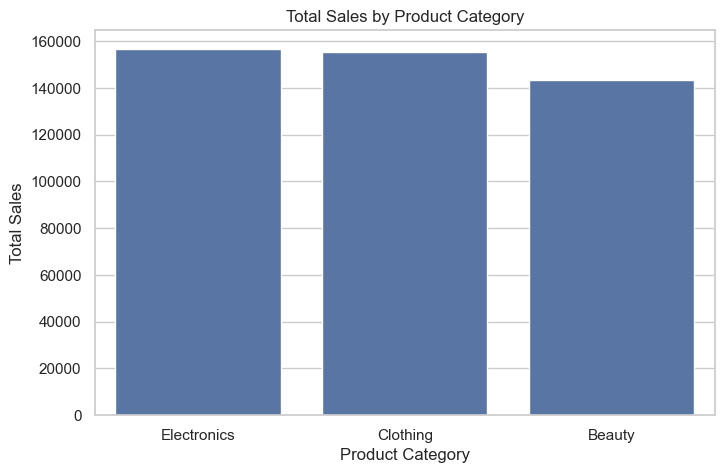

In [22]:
category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.show()

This chart compares the total sales generated by each product category.  
It shows that transaction frequency and revenue contribution are not always the same, so both should be considered in business analysis.

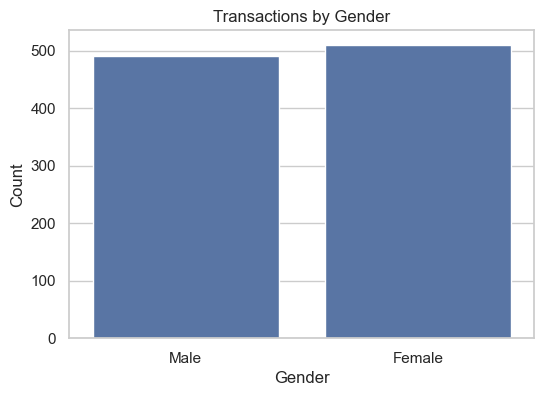

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender")
plt.title("Transactions by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

The number of transactions made by male and female customers is very similar.  
This suggests that the customer base in the dataset is relatively balanced by gender.

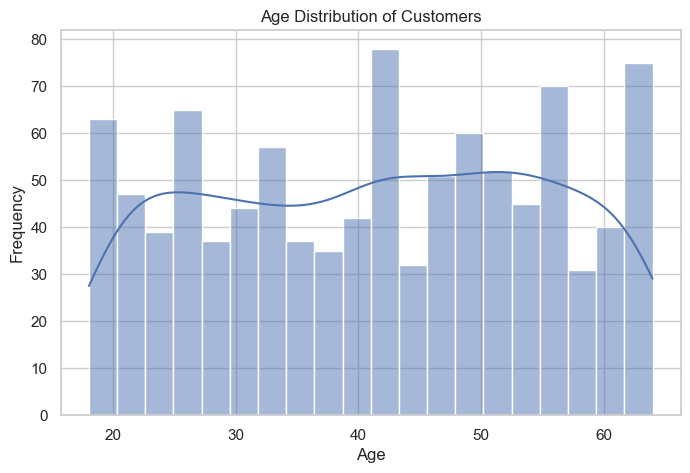

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The age distribution shows that customers are mainly adults and middle-aged individuals.  
This provides a general picture of the customer profile in the dataset.

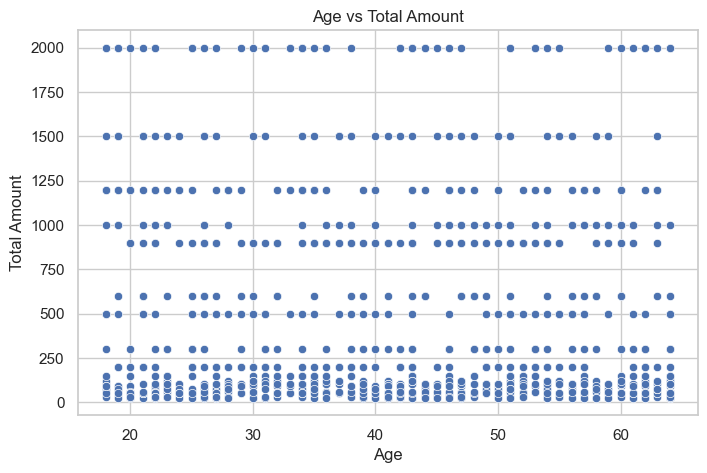

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Age", y="Total Amount")
plt.title("Age vs Total Amount")
plt.xlabel("Age")
plt.ylabel("Total Amount")
plt.show()

The scatter plot does not show a very strong relationship between age and transaction value.  
Customers of different ages appear to spend varying amounts, suggesting that age alone may not strongly predict spending.

In [26]:
gender_sales = df.groupby("Gender")["Total Amount"].mean()
gender_sales

Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64

In [27]:
avg_category_sales = df.groupby("Product Category")["Total Amount"].mean().sort_values(ascending=False)
avg_category_sales

Product Category
Beauty         467.475570
Electronics    458.786550
Clothing       443.247863
Name: Total Amount, dtype: float64

The average transaction amount differs slightly by gender and varies across product categories.  
This suggests that spending behaviour is influenced not only by customer characteristics, but also by the type of product purchased.

## Conclusion

This analysis explored retail transaction data to understand sales patterns, customer demographics, and product performance.  
The results show that product categories differ in both transaction frequency and sales contribution, while monthly sales also fluctuate over time.  
Overall, the analysis provides useful insights that can support retail decision-making.